<a href="https://colab.research.google.com/github/andysongyz-dev/brown-summer/blob/main/Team4_Spotify_Rec_1_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spotify Recommendation Engine

### Objective

______

### 1. Libraries

In [4]:
#import libraries

import pandas as pd
from sklearn.cluster import KMeans

### 2. Data Cleaning & Exploration

In [5]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
#import data and check

tracks_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/spotify_tracks.csv")

tracks_df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [7]:
#dimensions
print(f"rows, columns: {tracks_df.shape}")

rows, columns: (114000, 21)


In [8]:
#column names
print(tracks_df.columns.tolist())

['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [9]:
#describe the dataset
tracks_df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [10]:
#check dataset for missing values
import numpy as np
tracks_df = tracks_df.replace("unknown", np.nan)

In [11]:
#reveal important missing na values
tracks_df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,2
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


Create visualizations

In [12]:
#import libraries
import matplotlib.pyplot as plt
import seaborn as sns

#choose features we want
features_to_plot = [
    'popularity', 'danceability', 'energy', 'loudness', 'acousticness',
    'instrumentalness', 'valence', 'tempo'
]

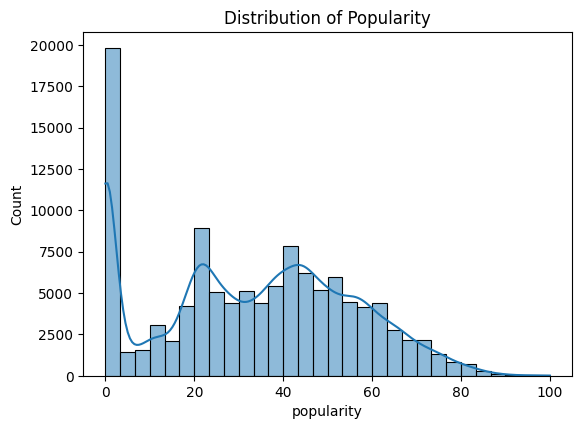

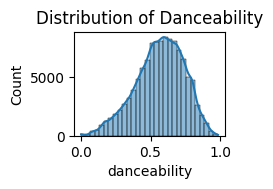

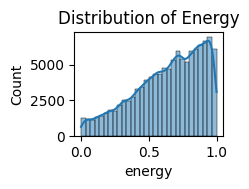

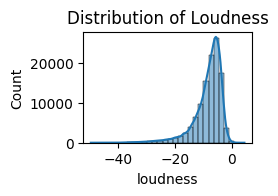

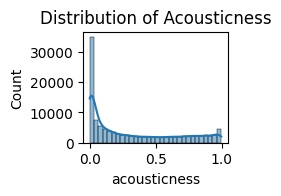

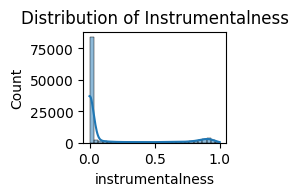

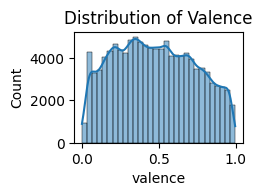

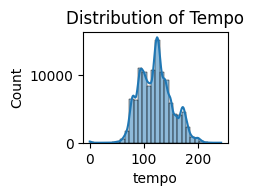

In [13]:
#create histogram
plt.figure(figsize=(16,12))

for i, col in enumerate(features_to_plot, 1):
  plt.subplot(3, 3, i)
  sns.histplot(data=tracks_df, x=col, kde=True, bins=30)
  plt.title(f'Distribution of {col.title()}')
  plt.xlabel(col)
  plt.ylabel('Count')

  plt.tight_layout()
  plt.show()

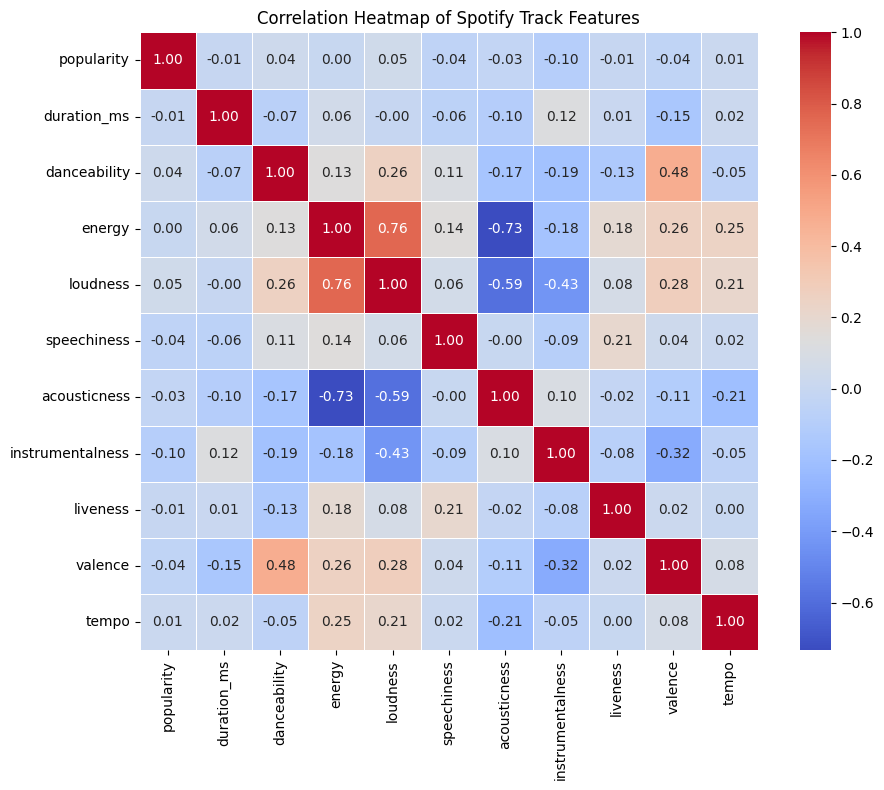

In [14]:
# Correlation heatmap

numerical_features = [
    'popularity', 'duration_ms', 'danceability', 'energy',
    'loudness', 'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]

#matrix
corr_matrix = tracks_df[numerical_features].corr()

#plot
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Spotify Track Features')
plt.tight_layout()
plt.show()
